In [40]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pennylane as qml

In [29]:
df = pd.read_csv("../data/train_prepared.csv", parse_dates=["Date"], low_memory=False)

df = df.sort_values(["Store","Date"])

split_date = "2015-06-01"

train_df = df[df["Date"] < split_date].copy()
val_df   = df[df["Date"] >= split_date].copy()

In [30]:
feature_cols = [
    "Sales",
    "Customers",
    "Promo",
    "day_of_week",
    "month",
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28"
]

In [31]:
# Sanity-check + clean features (NaNs here -> NaN loss in PyTorch)
for col in feature_cols:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
    val_df[col]   = pd.to_numeric(val_df[col], errors="coerce")

for name, frame in [("train", train_df), ("val", val_df)]:
    frame[feature_cols] = frame[feature_cols].replace([np.inf, -np.inf], np.nan)
    na_counts = frame[feature_cols].isna().sum().sort_values(ascending=False)
    rows_with_any_na = int(frame[feature_cols].isna().any(axis=1).sum())
    print(f"{name}: rows={len(frame):,} | rows with any NA in features={rows_with_any_na:,}")
    if rows_with_any_na:
        print(na_counts[na_counts > 0].head(20))

# Drop rows where any feature (incl target Sales) is missing
train_df = train_df.dropna(subset=feature_cols).copy()
val_df   = val_df.dropna(subset=feature_cols).copy()
print(f"After dropna: train rows={len(train_df):,} | val rows={len(val_df):,}")

train: rows=760,234 | rows with any NA in features=25,558
rolling_mean_28    25558
dtype: int64
val: rows=58,611 | rows with any NA in features=0
After dropna: train rows=734,676 | val rows=58,611


In [32]:
scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols]   = scaler.transform(val_df[feature_cols])

In [33]:
class RossmannDataset(Dataset):
    def __init__(self, df, feature_cols, seq_len):
        self.X = []
        self.y = []

        for store in df["Store"].unique():
            store_df = df[df["Store"] == store]

            data = store_df[feature_cols].values

            for i in range(len(data) - seq_len):
                x_seq = data[i:i+seq_len]
                y_tgt = data[i+seq_len][0]  # Sales target
                if np.isnan(x_seq).any() or np.isnan(y_tgt):
                    continue
                self.X.append(x_seq)
                self.y.append(y_tgt)

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [34]:
SEQ_LEN = 30
PRED_LEN = 1

train_dataset = RossmannDataset(train_df, feature_cols, SEQ_LEN)
val_dataset   = RossmannDataset(val_df, feature_cols, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)

In [35]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # last time step
        out = self.fc(out)
        return out.squeeze()

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(input_size=len(feature_cols)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [37]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item()
    
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}")

# Save trained model checkpoint after training completes
checkpoint = {
    "model_state_dict": model.state_dict(),
    "feature_cols": feature_cols,
    "seq_len": SEQ_LEN,
    "scaler": scaler,
}
torch.save(checkpoint, "../data/rossmann_lstm_checkpoint.pth")
print("Saved model checkpoint to ../data/rossmann_lstm_checkpoint.pth")

Epoch 1
Train Loss: 0.1235
Val Loss: 0.0724
Epoch 2
Train Loss: 0.0754
Val Loss: 0.0859
Epoch 3
Train Loss: 0.0658
Val Loss: 0.0640
Epoch 4
Train Loss: 0.0606
Val Loss: 0.0759
Epoch 5
Train Loss: 0.0574
Val Loss: 0.0816
Epoch 6
Train Loss: 0.0550
Val Loss: 0.0771
Epoch 7
Train Loss: 0.0531
Val Loss: 0.0824
Epoch 8
Train Loss: 0.0515
Val Loss: 0.0949
Epoch 9
Train Loss: 0.0501
Val Loss: 0.0906
Epoch 10
Train Loss: 0.0489
Val Loss: 0.0732
Saved model checkpoint to ../data/rossmann_lstm_checkpoint.pth


Saved validation predictions to ../data/val_predictions_lstm.csv


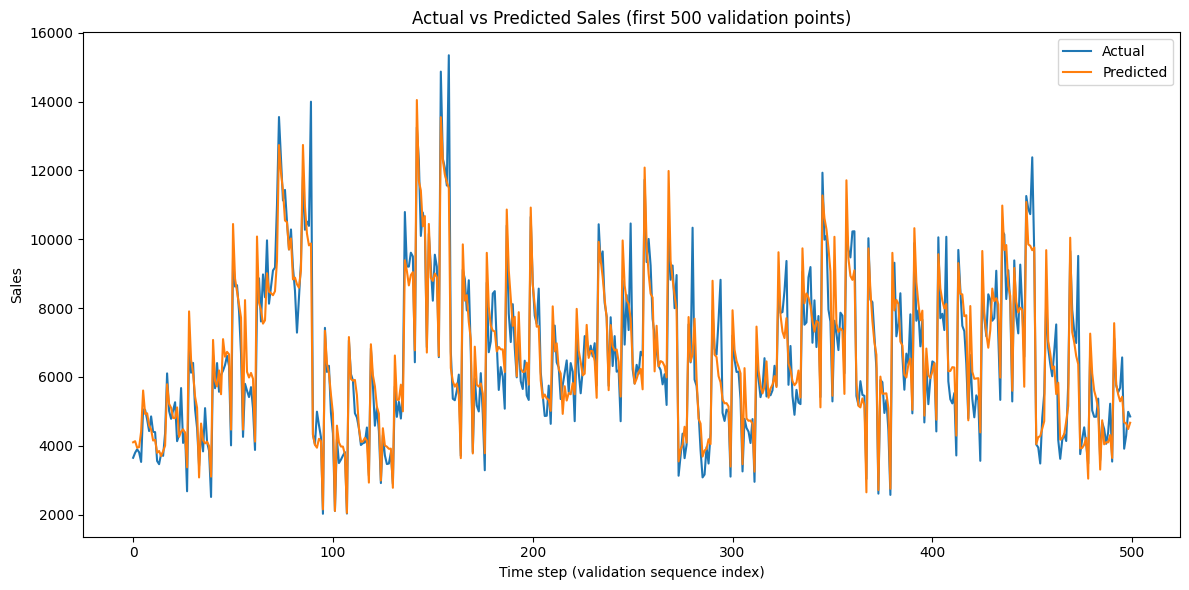

In [38]:
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

# Concatenate all batches
y_true_scaled = np.concatenate(all_targets)
y_pred_scaled = np.concatenate(all_preds)

# Inverse-scale to original Sales units using the fitted scaler
n = y_true_scaled.shape[0]
zeros = np.zeros((n, len(feature_cols) - 1), dtype=np.float32)

y_true_mat = np.concatenate([y_true_scaled.reshape(-1, 1), zeros], axis=1)
y_pred_mat = np.concatenate([y_pred_scaled.reshape(-1, 1), zeros], axis=1)

y_true = scaler.inverse_transform(y_true_mat)[:, 0]
y_pred = scaler.inverse_transform(y_pred_mat)[:, 0]

pred_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
})
pred_df.to_csv("../data/val_predictions_lstm.csv", index=False)
print("Saved validation predictions to ../data/val_predictions_lstm.csv")

# Plot a slice of the series for visual comparison
plt.figure(figsize=(12, 6))
plt.plot(pred_df["y_true"].values[:500], label="Actual")
plt.plot(pred_df["y_pred"].values[:500], label="Predicted")
plt.xlabel("Time step (validation sequence index)")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales (first 500 validation points)")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # inputs size must equal n_qubits
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [42]:
weight_shapes = {"weights": (n_layers, n_qubits, 3)}

In [43]:
class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(
            quantum_circuit,
            weight_shapes
        )

    def forward(self, x):
        return self.qlayer(x)

In [44]:
class QLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size=4):
        super().__init__()
        
        self.hidden_size = hidden_size
        
        # classical input projection to qubit size
        self.input_linear = nn.Linear(input_size + hidden_size, n_qubits)
        
        # four quantum gates
        self.q_forget = QuantumLayer()
        self.q_input  = QuantumLayer()
        self.q_output = QuantumLayer()
        self.q_cell   = QuantumLayer()
        
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        projected = self.input_linear(combined)

        f = self.sigmoid(self.q_forget(projected))
        i = self.sigmoid(self.q_input(projected))
        o = self.sigmoid(self.q_output(projected))
        g = self.tanh(self.q_cell(projected))

        c_next = f * c + i * g
        h_next = o * self.tanh(c_next)

        return h_next, c_next

In [45]:
class QLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=4):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.cell = QLSTMCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        for t in range(seq_len):
            h, c = self.cell(x[:, t, :], h, c)
        
        out = self.fc(h)
        return out.squeeze()

In [49]:
model = QLSTMModel(input_size=len(feature_cols)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [50]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item()
    
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}")

# Save trained model checkpoint after training completes
checkpoint = {
    "model_state_dict": model.state_dict(),
    "feature_cols": feature_cols,
    "seq_len": SEQ_LEN,
    "scaler": scaler,
}
torch.save(checkpoint, "../data/rossmann_lstm_checkpoint.pth")
print("Saved model checkpoint to ../data/rossmann_lstm_checkpoint.pth")

Epoch 1
Train Loss: 0.7508
Val Loss: 0.4408
Epoch 2
Train Loss: 0.4191
Val Loss: 0.2741


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

# Concatenate all batches
y_true_scaled = np.concatenate(all_targets)
y_pred_scaled = np.concatenate(all_preds)

# Inverse-scale to original Sales units using the fitted scaler
n = y_true_scaled.shape[0]
zeros = np.zeros((n, len(feature_cols) - 1), dtype=np.float32)

y_true_mat = np.concatenate([y_true_scaled.reshape(-1, 1), zeros], axis=1)
y_pred_mat = np.concatenate([y_pred_scaled.reshape(-1, 1), zeros], axis=1)

y_true = scaler.inverse_transform(y_true_mat)[:, 0]
y_pred = scaler.inverse_transform(y_pred_mat)[:, 0]

pred_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
})
pred_df.to_csv("../data/val_predictions_lstm.csv", index=False)
print("Saved validation predictions to ../data/val_predictions_lstm.csv")

# Plot a slice of the series for visual comparison
plt.figure(figsize=(12, 6))
plt.plot(pred_df["y_true"].values[:500], label="Actual")
plt.plot(pred_df["y_pred"].values[:500], label="Predicted")
plt.xlabel("Time step (validation sequence index)")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales (first 500 validation points)")
plt.legend()
plt.tight_layout()
plt.show()